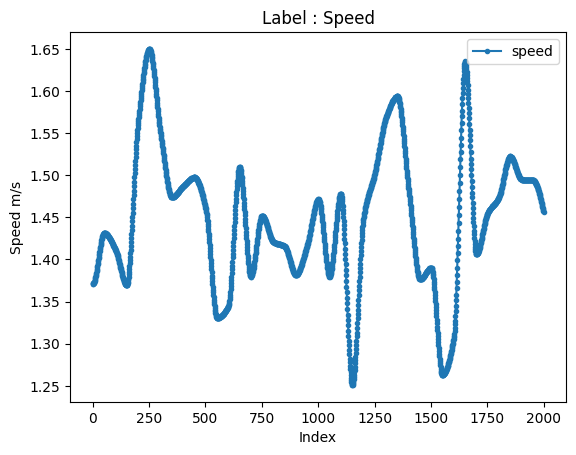

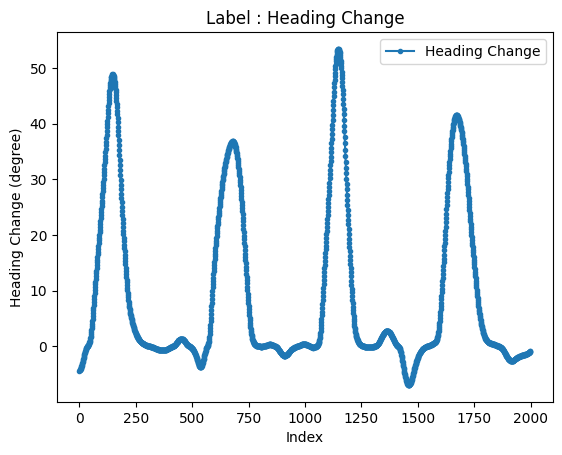

Y[100] → speed: 1.4535 m/s, heading: 24.3551 degree
Y[101] → speed: 1.4533 m/s, heading: 24.9296 degree
Y[102] → speed: 1.4534 m/s, heading: 25.4735 degree
Y[103] → speed: 1.4537 m/s, heading: 26.0952 degree
Y[104] → speed: 1.4540 m/s, heading: 26.5523 degree
Y[105] → speed: 1.4546 m/s, heading: 27.0874 degree
Y[106] → speed: 1.4553 m/s, heading: 27.6197 degree
Y[107] → speed: 1.4561 m/s, heading: 28.1758 degree
Y[108] → speed: 1.4572 m/s, heading: 28.7289 degree
Y[109] → speed: 1.4582 m/s, heading: 29.2008 degree
Y[110] → speed: 1.4594 m/s, heading: 29.7227 degree
Y[111] → speed: 1.4608 m/s, heading: 30.2421 degree
Y[112] → speed: 1.4623 m/s, heading: 30.7590 degree
Y[113] → speed: 1.4639 m/s, heading: 31.2991 degree
Y[114] → speed: 1.4657 m/s, heading: 31.8365 degree
Y[115] → speed: 1.4674 m/s, heading: 32.2950 degree
Y[116] → speed: 1.4694 m/s, heading: 32.8275 degree
Y[117] → speed: 1.4713 m/s, heading: 33.3070 degree
Y[118] → speed: 1.4734 m/s, heading: 33.8094 degree
Y[119] → spe

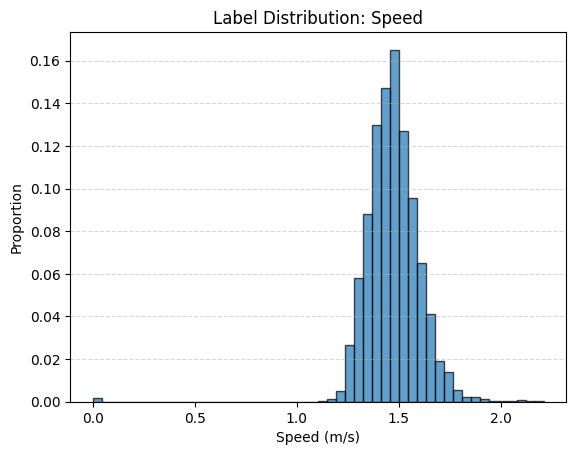

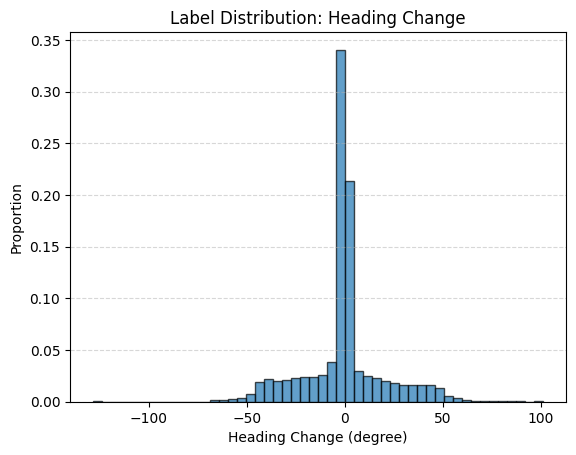

In [1]:
from src.data_processor import DataProcessor
from src.model_trainer import ModelTrainer
from src.trajectory_predictor import TrajectoryPredictor
import numpy as np
import os
import random
import tensorflow as tf
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# 현재 main.py 파일의 디렉토리를 기준으로 프로젝트 루트 경로 설정
BASE_DIR = os.getcwd()

# 시드 값 고정
SEED = 1217  
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

def main():
    # ============================================================
    # 1. 학습 데이터 로딩 및 전처리
    # ============================================================
    learn_data_paths = [
        # os.path.join(BASE_DIR, 'data', 'learn_data', 'Basket_1.csv'),
        # os.path.join(BASE_DIR, 'data', 'learn_data', 'Basket_2.csv'),
        # os.path.join(BASE_DIR, 'data', 'learn_data', 'Soccer_looking1.csv'),
        # os.path.join(BASE_DIR, 'data', 'learn_data', 'Soccer_looking3.csv'),
        # os.path.join(BASE_DIR, 'data', 'learn_data', 'Soccer_looking4.csv'),
        os.path.join(BASE_DIR, 'data', 'learn_data', 'Soccer_looking5m_01.csv'),
        os.path.join(BASE_DIR, 'data', 'learn_data', 'Soccer_looking5m_02.csv'),
        os.path.join(BASE_DIR, 'data', 'learn_data', 'Soccer_looking5m_03.csv'),
        # os.path.join(BASE_DIR, 'data', 'learn_data', 'Soccer_swing5m_01.csv'),
        # os.path.join(BASE_DIR, 'data', 'learn_data', 'Soccer_swing5m_02.csv'),
        # os.path.join(BASE_DIR, 'data', 'learn_data', 'Soccer_swing5m_03.csv'),
        # os.path.join(BASE_DIR, 'data', 'learn_data', 'Soccer_swing1.csv'),
        # os.path.join(BASE_DIR, 'data', 'learn_data', 'Soccer_swing2.csv'),
        # os.path.join(BASE_DIR, 'data', 'learn_data', 'Soccer_swing3.csv'),
        # os.path.join(BASE_DIR, 'data', 'learn_data', 'Soccer_swing4.csv'),
    ]

    df_list = []
    for path in learn_data_paths:
        if os.path.exists(path):
            # CSV 파일 로딩 및 전처리 (skiprows: 처음 100행 스킵)
            df = DataProcessor.load_and_preprocess_csv(path, skiprows=300)
            df_list.append(df)
        else:
            print(f"파일을 찾을 수 없습니다: {path}")

    # ============================================================
    # 2. 슬라이딩 윈도우 방식으로 X, Y 데이터 생성
    # ============================================================
    X_list, Y_list = [], []
    for df in df_list:
        X_sub, Y_sub = DataProcessor.make_XY_using_dataframe(df)
        X_list.append(X_sub)
        Y_list.append(Y_sub)

    if not X_list:
        print("학습 데이터를 불러오지 못했습니다.")
        return

    X = np.concatenate(X_list, axis=0)
    Y = np.concatenate(Y_list, axis=0)
    
    plt.plot(Y[:, 0][3000:5000], '.-', label='speed')
    plt.title('Label : Speed')
    plt.xlabel('Index')
    plt.ylabel('Speed m/s')
    plt.legend()
    plt.show()
    
    plt.plot(np.degrees(Y[:, 1][3000:5000]), '.-', label='Heading Change')
    plt.title('Label : Heading Change')
    plt.xlabel('Index')
    plt.ylabel('Heading Change (degree)')
    plt.legend()
    plt.show()
    
    for i, (speed, heading) in enumerate(Y[250:500]):
        print(f"Y[{i+100}] → speed: {speed:.4f} m/s, heading: {np.degrees(heading):.4f} degree")
        
    heading_deg = np.degrees(Y[:, 1])

    # 2) 임계치 10도
    threshold = 10.0

    # 3) 카운트
    n_large = np.sum(np.abs(heading_deg) >= threshold)
    n_small = np.sum(np.abs(heading_deg) <  threshold)
    n_total = len(heading_deg)

    # 4) 결과 출력
    print(f"전체 샘플 수: {n_total}")
    print(f"|Δθ| ≥ {threshold}° 샘플 수: {n_large}  ({n_large/n_total*100:.1f}%)")
    print(f"  Δθ <  {threshold}° 샘플 수: {n_small}  ({n_small/n_total*100:.1f}%)")

    # 1) Speed 분포
    speeds = Y[:, 0]
    # bins 설정 (50개 구간)
    bins = np.linspace(speeds.min(), speeds.max(), 51)
    hist, edges = np.histogram(speeds, bins=bins, density=False)
    # 비율(proportion)로 변환
    hist = hist / hist.sum()
    # 구간 중앙값
    centers = (edges[:-1] + edges[1:]) / 2

    plt.figure()
    plt.bar(centers, hist, width=edges[1]-edges[0], edgecolor='k', alpha=0.7)
    plt.title('Label Distribution: Speed')
    plt.xlabel('Speed (m/s)')
    plt.ylabel('Proportion')
    plt.grid(True, axis='y', linestyle='--', alpha=0.5)
    plt.show()

    # 2) Heading Change 분포
    heading_deg = np.degrees(Y[:, 1])
    bins = np.linspace(heading_deg.min(), heading_deg.max(), 51)
    hist, edges = np.histogram(heading_deg, bins=bins, density=False)
    hist = hist / hist.sum()
    centers = (edges[:-1] + edges[1:]) / 2

    plt.figure()
    plt.bar(centers, hist, width=edges[1]-edges[0], edgecolor='k', alpha=0.7)
    plt.title('Label Distribution: Heading Change')
    plt.xlabel('Heading Change (degree)')
    plt.ylabel('Proportion')
    plt.grid(True, axis='y', linestyle='--', alpha=0.5)
    plt.show()
    
if __name__ == '__main__':
    main()
